In [34]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

## Ejercicio 8 - Péndulo doble y movimiento caótico.

Sea un péndulo doble:

* Consiste en dos péndulos ideales de masas $m_1$ y $m_2$, siendo la masa del primer péndulo el punto de pivote del segundo.  
  La rotación de ambos péndulos se considera sin fricción.
  
  
* Ambos están conectados por dos varillas rígidas de masa despreciable y longitud $L_1$ y $L_2$.
  
  
* El desplazamiento angular de cada péndulo con respecto al eje vertical se denota como $\theta_1$ y $\theta_2$, respectivamente.


* El sistema se puede caracterizar de forma unívoca por medio de estos dos grados de libertad, $\theta_1$ y $\theta_2$.  
    Sin embargo esta asociado a un movimiento caótico.

El movimiento del sistema viene dado por las ecuaciones:

\begin{align}
\ddot{\theta_1} =& \frac{1}{L_1\eta}\left[L_1\,m_2\,c_{12}\,s_{12}\,\dot{\theta}_1^2+L_2\,m_2\,s_{12}\,\dot{\theta}_2^2+(m_1+m_2)\,g\,\sin\left(\theta_1\right)-m_2\,g\,c_{12}\,\sin\left(\theta_2\right)\right]\nonumber\\
\ddot{\theta_2} =& \frac{-1}{L_2\eta}\left[L_1\,(m_1+m_2)\,s_{12}\,\dot{\theta}_1^2+L_2\,m_2\,\, c_{12}\,s_{12}\,\dot{\theta}_2^2+(m_1+m_2)\,g\,c_{12}\,\sin\left(\theta_1\right)-(m_1+m_2)\,g\,\sin\left(\theta_2\right)\right]\nonumber
\end{align}

siendo 

$$c_{12}=\cos\left(\theta_1-\theta_2\right),\quad s_{12}=\sin\left(\theta_1-\theta_2\right),\quad\text{y}\quad \eta=c_{12}^2\,m_2-m_1-m_2$$

En primer lugar vamos a estudiar la evolución del sistema partiendo de las condiciones iniciales: 

$$\theta_1(0)=\theta_2(0)=0\,\text{rad},\quad \dot\theta_1(0)=0\,\text{rad/s},\quad \dot\theta_2(0)= 0.1\,\text{rad/s}.$$

es decir, cuando la perturbación que aplicamos al sistema con respecto al equilibrio es pequeña. 

---

1. Usando los valores siguientes:

   $m_1=2\,\text{Kg},\quad m_2=3\,\text{Kg},\quad L_1=2\,\text{m},\quad L_2=1\,\text{m} \quad g=9.81\,\text{m}\,s^{-2}$ 

   resolver las ecuaciones de movimiento durante un periodo de 1 min.  
   Representar la evolución del sistema (la evolución de las coordenadas $\theta_1$ y $\theta_2$) durante los últimos 10 s de este periodo de tiempo
   Explicar por qué se ha elegido el método numérico empleado para resolver el sistema de ecuaciones y el espaciado temporal considerado.  
   ¿Cuál es la precisión esperada del resultado?

---

2. Representar también durante los últimos 10 s la posición en coordenadas cartesianas de ambos péndulos en cada instante y el espacio de fase para las variables $\theta_1$ y $\theta_2$ ($\theta_i'$ con respecto a $\theta_i$). ¿Es un movimiento periódico?

---

3. Representar en este periodo la energía cinética, potencial y total del sistema.   
   Comprobar si la energía total se conserva con el método númerico empleado y explicar por qué.

   En segundo lugar vamos a comprobar que ocurre cuando inicialmente desplazamos el sistema lejos del punto de equilibrio.

---

4. Usando los mismos valores para el sistema del apartado 1 y las condicione iniciales

   $$\theta_1(0)=45^\circ,\quad\theta_2(0)=0^\circ,\quad \dot\theta_1(0)=\dot\theta_2(0)=0\,\text{rad/s}.$$

   Representar de nuevo la evolución del sistema (su desplazamiento angular, sus coordenadas polares y su espacio de fases).

---

5. Finalmente comprobemos que ocurre si variamos ligeramente las condiciones iniciales a 
$$\theta_1(0)=45^\circ,\quad\theta_2(0)=5^\circ,\quad \dot\theta_1(0)=\dot\theta_2(0)=0\,\text{rad/s}.$$

   Comprobar el comportamiento  del sistema (su desplazamiento angular, sus coordenadas polares y su espacio de fases) para ambas condiciones iniciales. 
   ¿Qué implicaciones tiene? ¿Qué le ocurriría al sistema de forma asintótica cuando variamos las condiciones iniciales de forma infinitesimal?.

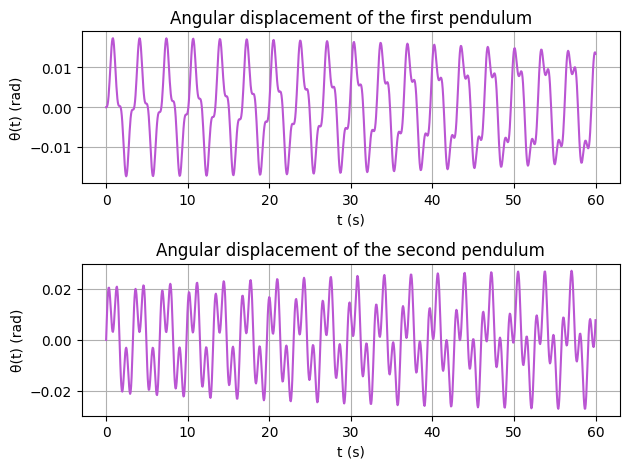

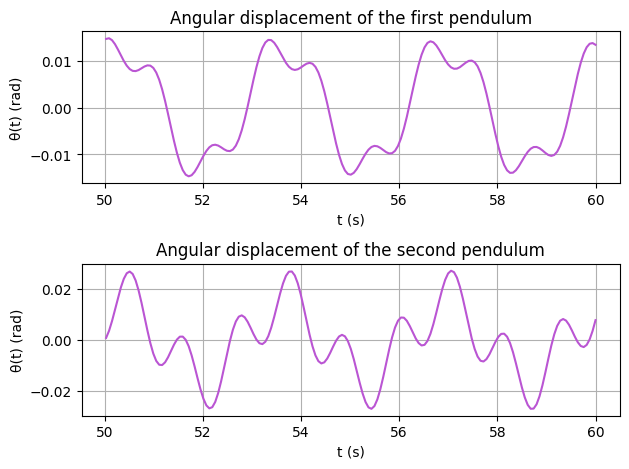

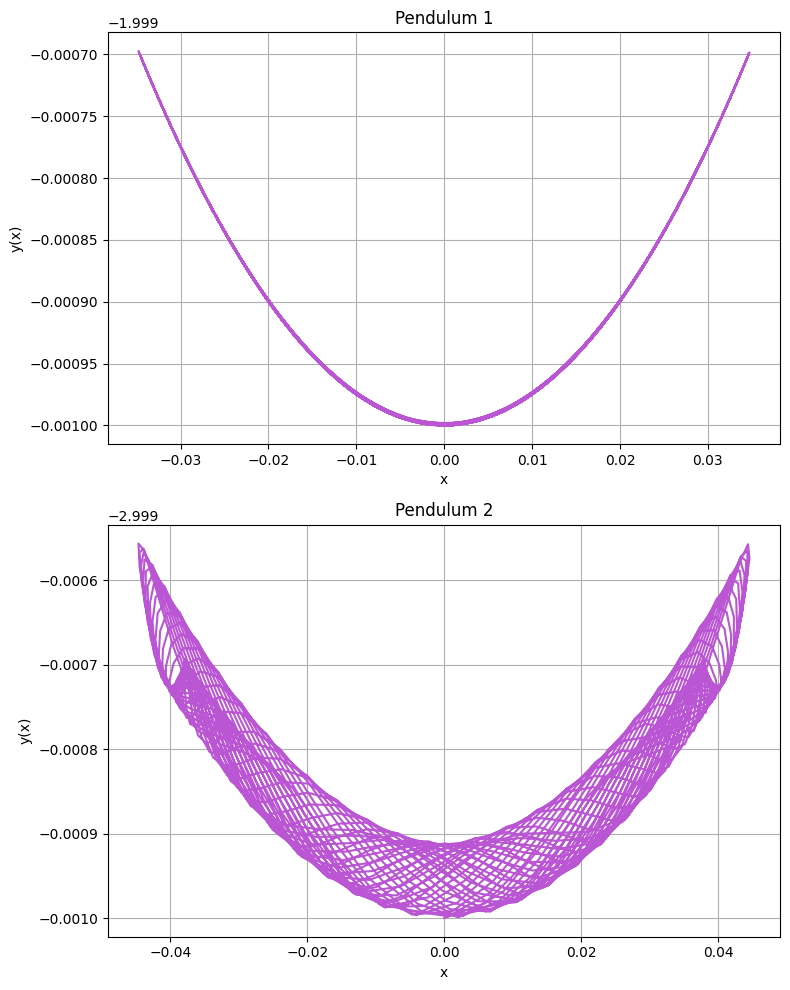

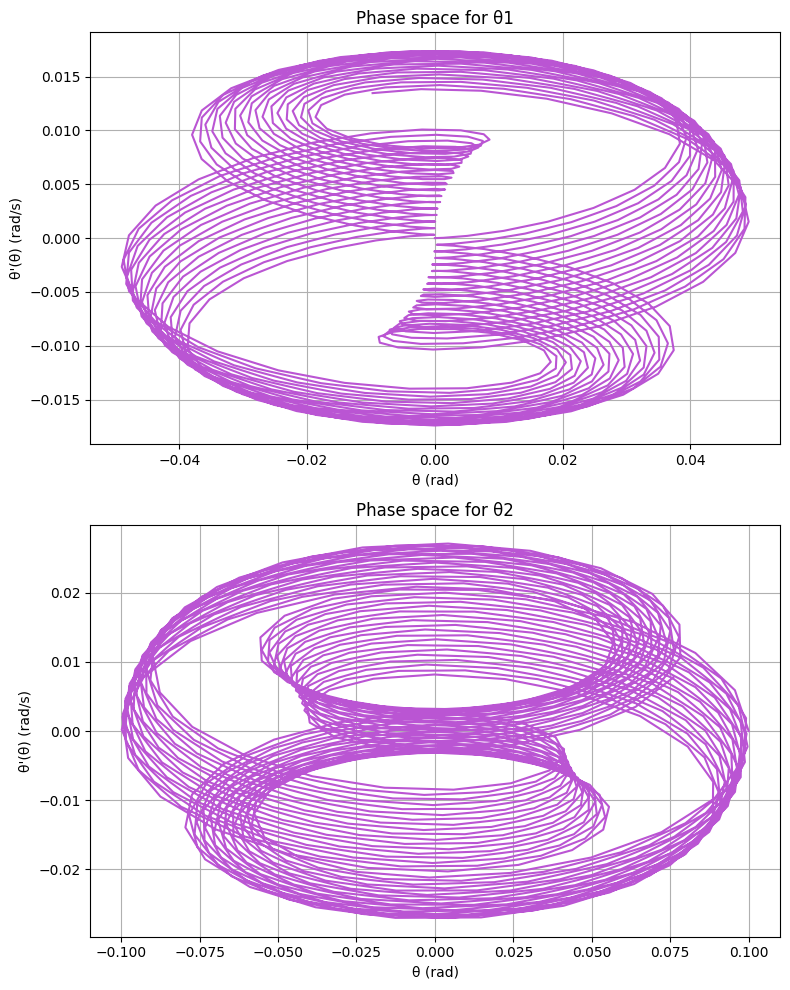

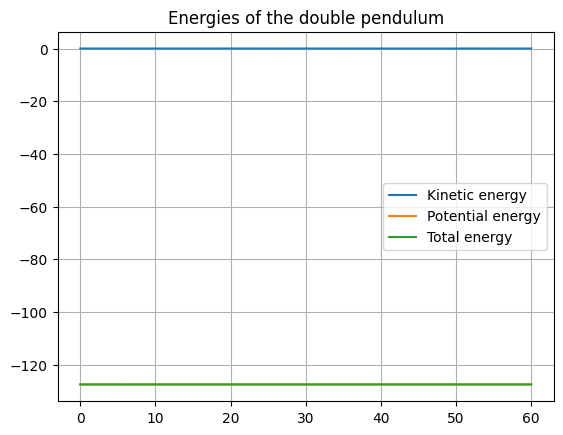

In [31]:
m1, m2 = 2, 3
L1, L2 = 2, 1
g = 9.81

t10, t20 = 0, 0
vt10, vt20 = 0, 0.1


r = np.array([t10, t20, vt10, vt20])

def F(r, t):
    t1 = r[0]
    t2 = r[1]
    vt1 = r[2]
    vt2 = r[3]

    c12 = np.cos(t1 - t2)
    s12 = np.sin(t1 - t2)
    eta = (m2 * c12**2) - m1 - m2

    ft1 = vt1
    ft2 = vt2
    fvt1 = (m2 * s12 * (L1 * c12 * vt1**2 + L2 * vt2**2) + g * ((m1 + m2) * np.sin(t1) - m2 * c12 * np.sin(t2))) / (L1 * eta)
    fvt2 = -((m1 + m2) * (L1 * s12 * vt1**2 + g * (c12 * np.sin(t1) - np.sin(t2))) + L2 * m2 * c12 * s12 * vt2**2) / (L2 * eta)
    return np.array([ft1, ft2, fvt1, fvt2], float)

def double_pendulum(F, a, b, N, r):
    h = (b - a) / N
    time = np.linspace(a, b, N)
    t1p, t2p, vt1p, vt2p = [], [], [], []
    r = np.array(r, float)

    xc1, yc1, xc2, yc2 = [], [], [], []

    T, V, E = [], [], []

    for t in time:
        t1p.append(r[0])
        t2p.append(r[1])
        vt1p.append(r[2])
        vt2p.append(r[3])

        xc1.append(L1 * np.sin(r[0]))
        yc1.append(-L1 * np.cos(r[0]))
        xc2.append(L1 * np.sin(r[0]) + L2 * np.sin(r[1]))
        yc2.append(-L1 * np.cos(r[0]) - L2 * np.cos(r[1]))

        kinetic = (m1 * (L1 * r[2])**2) / 2 + ((L1 * r[2])**2 + (L2 * r[3])**2 + 2 * L1 * L2 * r[0] * r[1] * np.cos(r[0] - r[1])) * m2 / 2
        potential = -(m1 + m2) * g * L1 * np.cos(r[0]) - m2 * g * L2 * np.cos(r[1])
        T.append(kinetic)
        V.append(potential)
        E.append(kinetic + potential)

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return time, t1p, t2p, vt1p, vt2p, xc1, yc1, xc2, yc2, T, V, E

N = 1000
time, theta1, theta2, theta1_dot, theta2_dot, xc1, yc1, xc2, yc2, T, V, E = double_pendulum(F, 0, 60, N, r)

plt.subplot(2, 1, 1)
plt.plot(time, theta1, color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time, theta2, color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.subplot(2, 1, 1)
plt.plot(time[int(5 * len(time) / 6):], theta1[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time[int(5 * len(time) / 6):], theta2[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(xc1, yc1, color = mc)
plt.grid()
plt.title("Pendulum 1")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.subplot(2, 1, 2)
plt.plot(xc2, yc2, color = mc)
plt.grid()
plt.title("Pendulum 2")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(theta1_dot, theta1, color = mc)
plt.grid()
plt.title("Phase space for θ1")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.subplot(2, 1, 2)
plt.plot(theta2_dot, theta2, color = mc)
plt.grid()
plt.title("Phase space for θ2")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.tight_layout()
plt.show()

plt.plot(time, T)
plt.plot(time, V)
plt.plot(time, E)
plt.title("Energies of the double pendulum")
plt.legend(["Kinetic energy", "Potential energy", "Total energy"])
plt.grid()
plt.show()

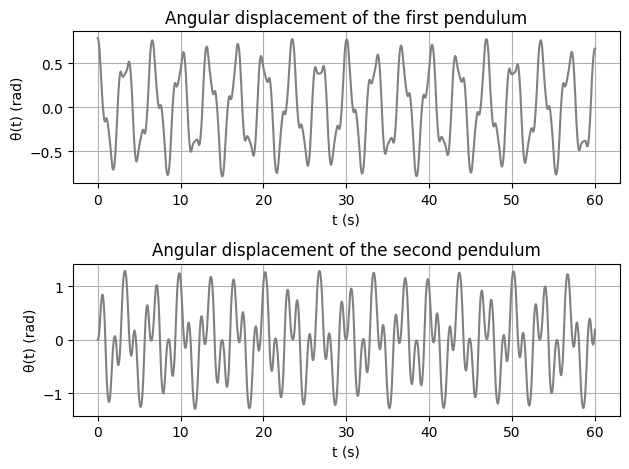

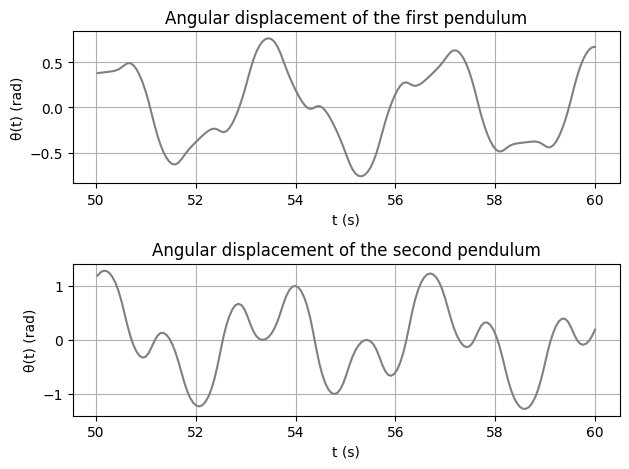

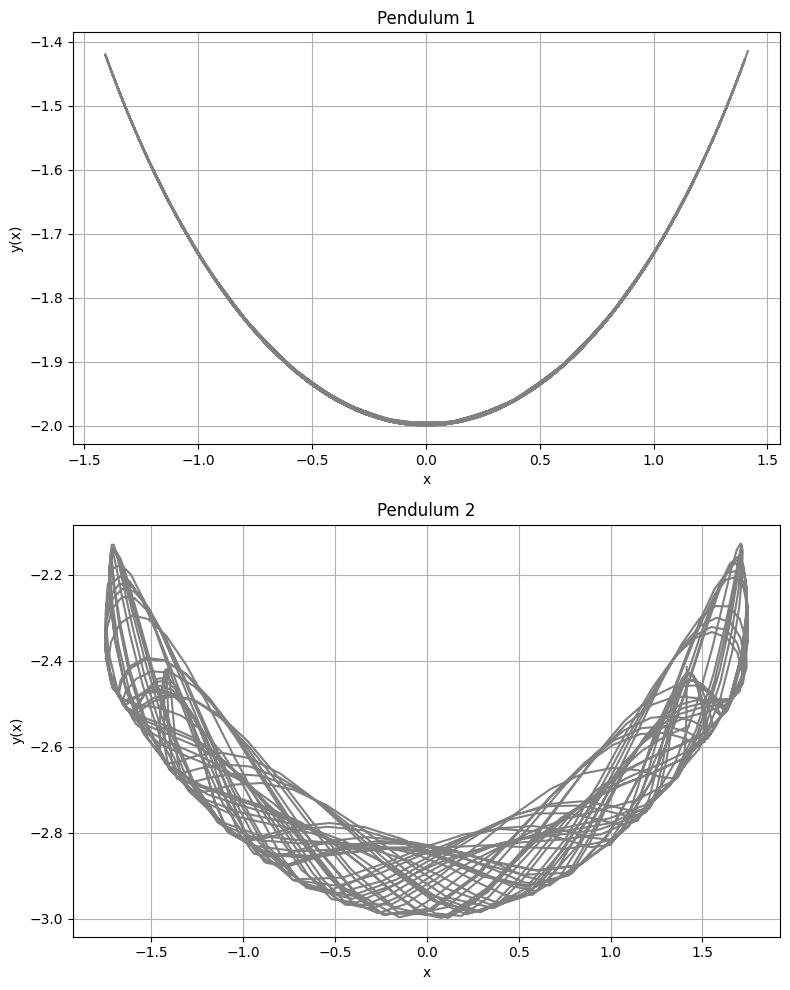

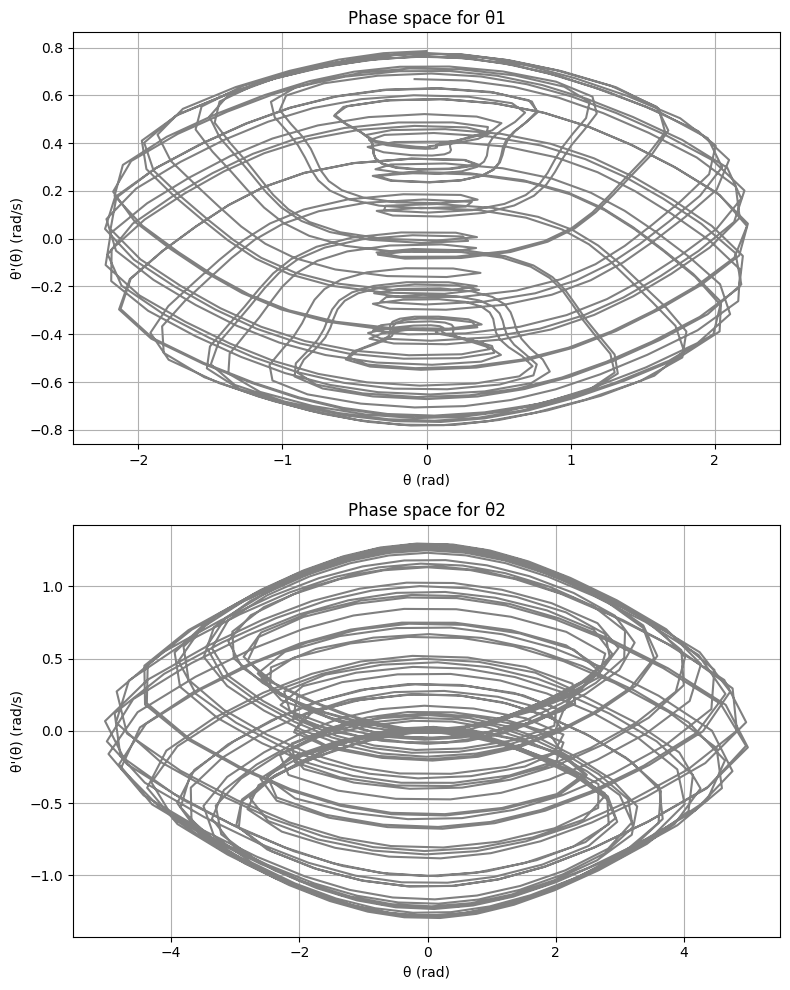

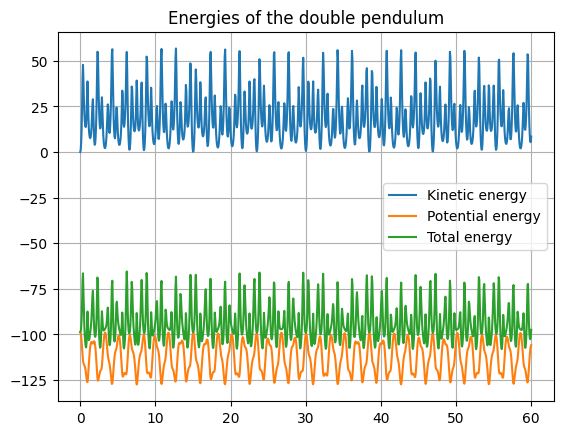

In [32]:
t10, t20 = np.pi / 4, 0
vt10, vt20 = 0, 0
r = np.array([t10, t20, vt10, vt20])
mc = 'gray'
time, theta1, theta2, theta1_dot, theta2_dot, xc1, yc1, xc2, yc2, T, V, E = double_pendulum(F, 0, 60, N, r)

plt.subplot(2, 1, 1)
plt.plot(time, theta1, color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time, theta2, color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.subplot(2, 1, 1)
plt.plot(time[int(5 * len(time) / 6):], theta1[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time[int(5 * len(time) / 6):], theta2[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(xc1, yc1, color = mc)
plt.grid()
plt.title("Pendulum 1")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.subplot(2, 1, 2)
plt.plot(xc2, yc2, color = mc)
plt.grid()
plt.title("Pendulum 2")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(theta1_dot, theta1, color = mc)
plt.grid()
plt.title("Phase space for θ1")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.subplot(2, 1, 2)
plt.plot(theta2_dot, theta2, color = mc)
plt.grid()
plt.title("Phase space for θ2")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.tight_layout()
plt.show()

plt.plot(time, T)
plt.plot(time, V)
plt.plot(time, E)
plt.title("Energies of the double pendulum")
plt.legend(["Kinetic energy", "Potential energy", "Total energy"])
plt.grid()
plt.show()

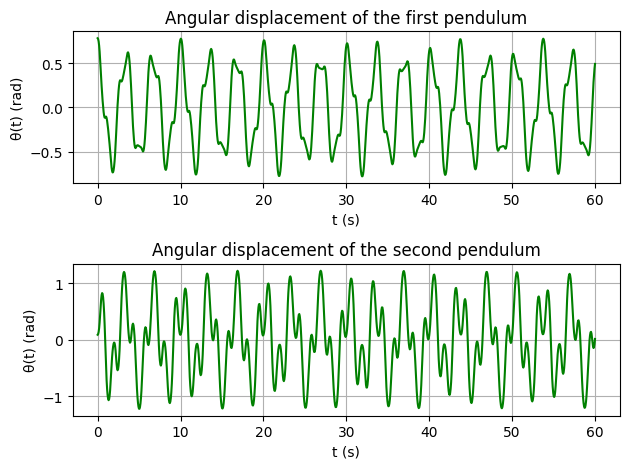

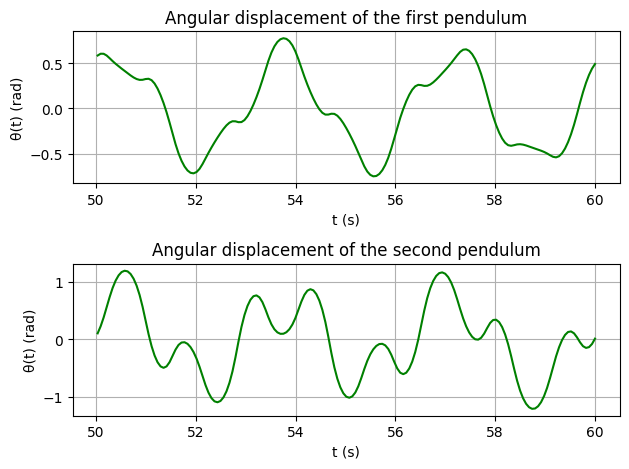

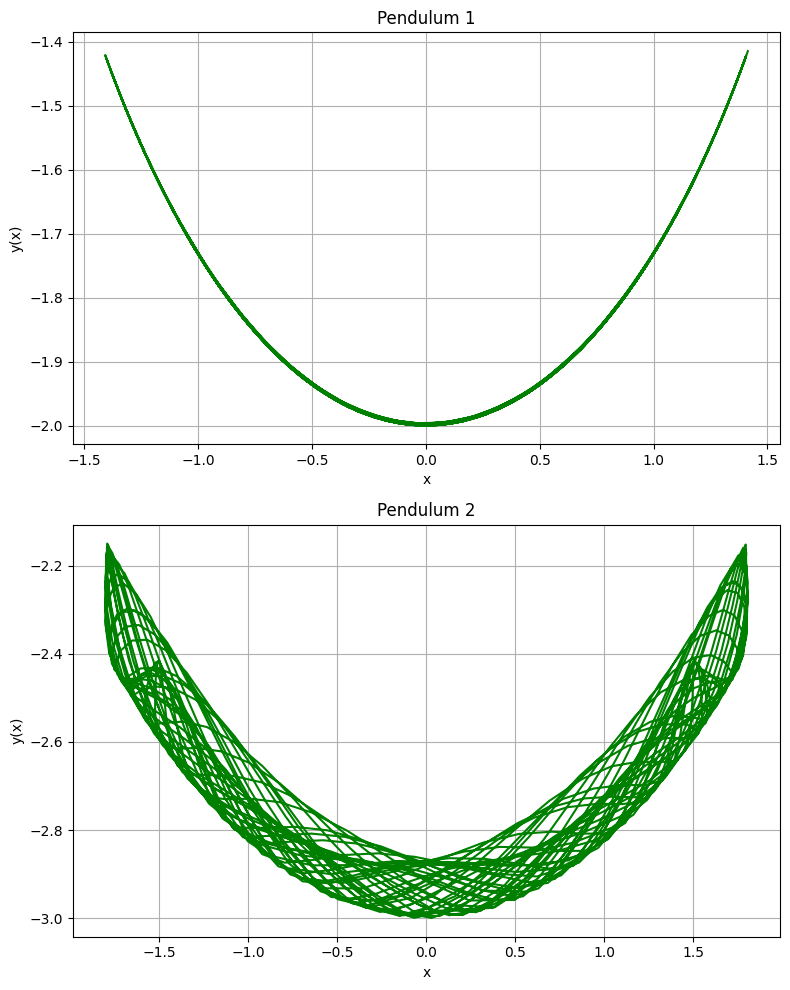

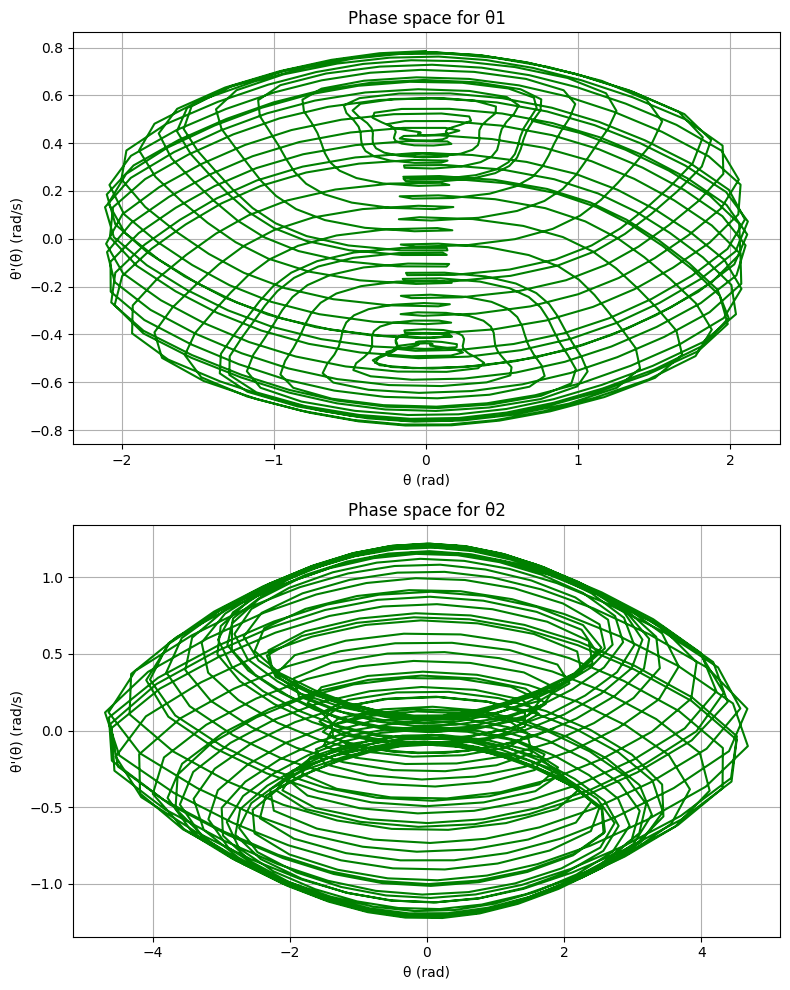

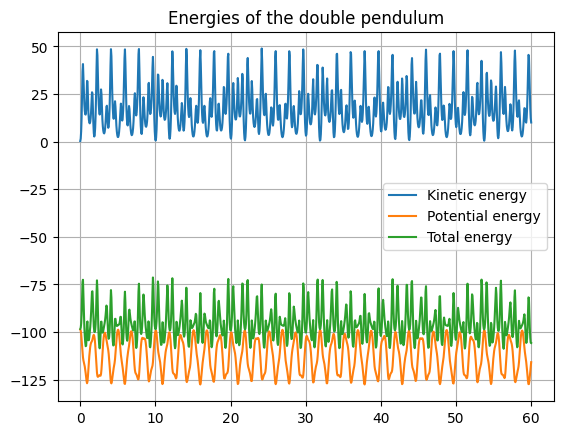

In [33]:
t10, t20 = np.pi / 4, np.pi * 5 / 180
vt10, vt20 = 0, 0
r = np.array([t10, t20, vt10, vt20])
mc = 'green'
time, theta1, theta2, theta1_dot, theta2_dot, xc1, yc1, xc2, yc2, T, V, E = double_pendulum(F, 0, 60, N, r)

plt.subplot(2, 1, 1)
plt.plot(time, theta1, color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time, theta2, color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.subplot(2, 1, 1)
plt.plot(time[int(5 * len(time) / 6):], theta1[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the first pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.subplot(2, 1, 2)
plt.plot(time[int(5 * len(time) / 6):], theta2[int(5 * len(time) / 6):], color = mc)
plt.grid()
plt.title("Angular displacement of the second pendulum")
plt.ylabel("θ(t) (rad)")
plt.xlabel("t (s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(xc1, yc1, color = mc)
plt.grid()
plt.title("Pendulum 1")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.subplot(2, 1, 2)
plt.plot(xc2, yc2, color = mc)
plt.grid()
plt.title("Pendulum 2")
plt.ylabel("y(x)")
plt.xlabel("x")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(theta1_dot, theta1, color = mc)
plt.grid()
plt.title("Phase space for θ1")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.subplot(2, 1, 2)
plt.plot(theta2_dot, theta2, color = mc)
plt.grid()
plt.title("Phase space for θ2")
plt.ylabel("θ'(θ) (rad/s)")
plt.xlabel("θ (rad)")
plt.tight_layout()
plt.show()

plt.plot(time, T)
plt.plot(time, V)
plt.plot(time, E)
plt.title("Energies of the double pendulum")
plt.legend(["Kinetic energy", "Potential energy", "Total energy"])
plt.grid()
plt.show()